In [2]:
import pandas as pd ;

In [3]:
df = pd.read_csv(r"C:\Users\DELL\Downloads\fraud detection project\archive (1)\creditcard.csv")

In [13]:
df.shape

(284807, 31)

In [14]:
df.info

<bound method DataFrame.info of             Time         V1         V2        V3        V4        V5  \
0            0.0  -1.359807  -0.072781  2.536347  1.378155 -0.338321   
1            0.0   1.191857   0.266151  0.166480  0.448154  0.060018   
2            1.0  -1.358354  -1.340163  1.773209  0.379780 -0.503198   
3            1.0  -0.966272  -0.185226  1.792993 -0.863291 -0.010309   
4            2.0  -1.158233   0.877737  1.548718  0.403034 -0.407193   
...          ...        ...        ...       ...       ...       ...   
284802  172786.0 -11.881118  10.071785 -9.834783 -2.066656 -5.364473   
284803  172787.0  -0.732789  -0.055080  2.035030 -0.738589  0.868229   
284804  172788.0   1.919565  -0.301254 -3.249640 -0.557828  2.630515   
284805  172788.0  -0.240440   0.530483  0.702510  0.689799 -0.377961   
284806  172792.0  -0.533413  -0.189733  0.703337 -0.506271 -0.012546   

              V6        V7        V8        V9  ...       V21       V22  \
0       0.462388  0.239599  

In [15]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [16]:
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [17]:
df['Class'].value_counts(normalize=True)

Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64

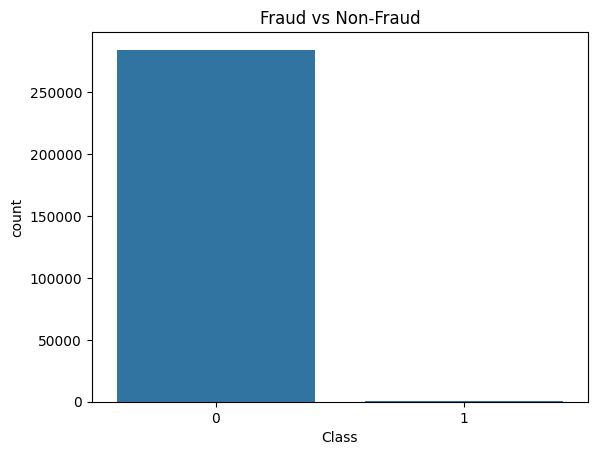

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Class', data=df)
plt.title("Fraud vs Non-Fraud")
plt.show()

In [20]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [22]:
df['Amount'].describe()

count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64

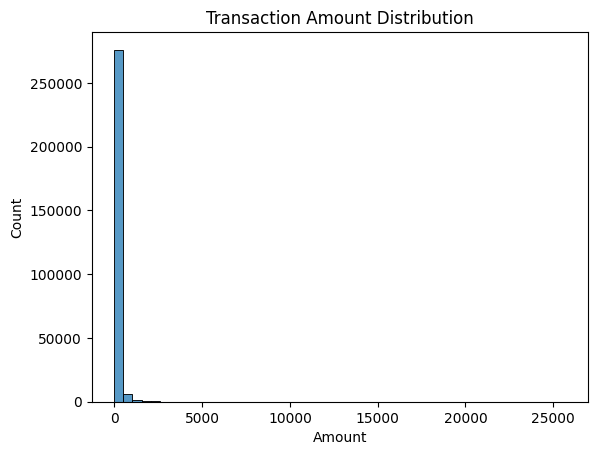

In [23]:
sns.histplot(df['Amount'], bins=50)
plt.title("Transaction Amount Distribution")
plt.show()

In [24]:
df.groupby('Class')['Amount'].mean()

Class
0     88.291022
1    122.211321
Name: Amount, dtype: float64

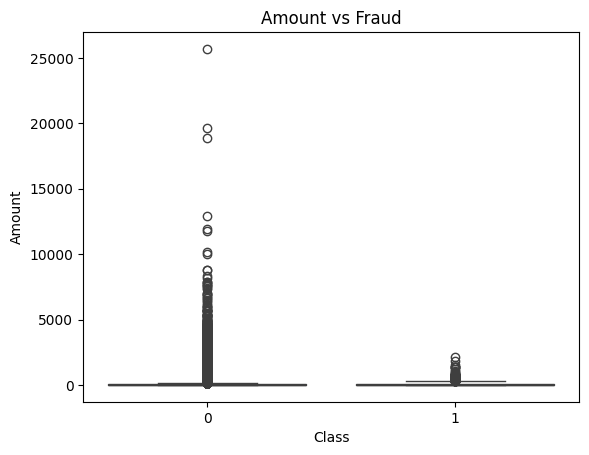

In [25]:
sns.boxplot(x='Class', y='Amount', data=df)
plt.title("Amount vs Fraud")
plt.show()

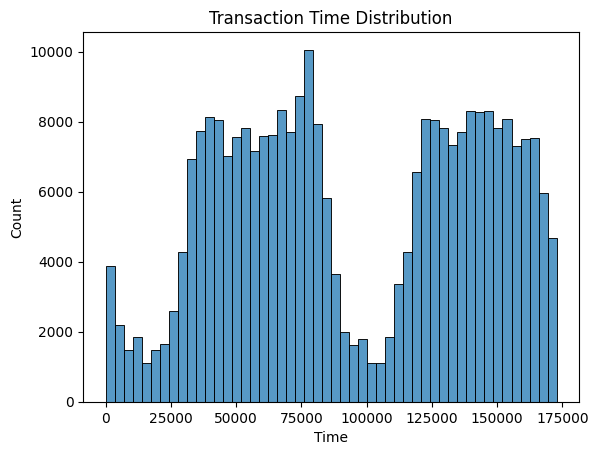

In [26]:
sns.histplot(df['Time'], bins=50)
plt.title("Transaction Time Distribution")
plt.show()

In [27]:
df['Hour'] = df['Time'] // 3600
df['Hour'] = df['Hour'] % 24

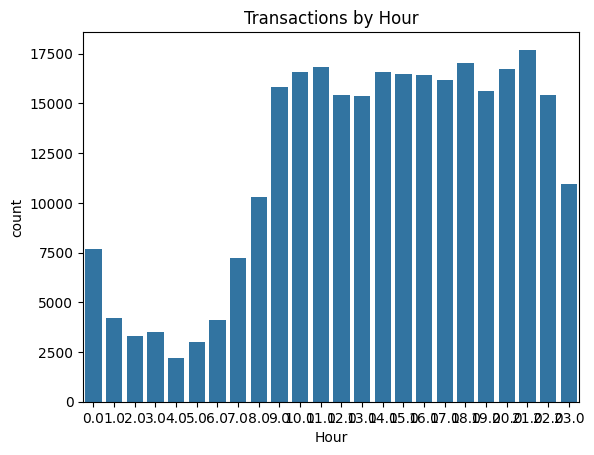

In [28]:
sns.countplot(x='Hour', data=df)
plt.title("Transactions by Hour")
plt.show()

In [7]:
X = df.drop('Class', axis=1)
y = df['Class']

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [32]:
pip install scikit-learn imbalanced-learn

   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.0 MB 2.8 MB/s eta 0:00:03
   ----- ---------------------------------- 1.0/8.0 MB 2.5 MB/s eta 0:00:03
   --------- ------------------------------ 1.8/8.0 MB 2.9 MB/s eta 0:00:03
   ----------- ---------------------------- 2.4/8.0 MB 3.0 MB/s eta 0:00:02
   --------------- ------------------------ 3.1/8.0 MB 2.9 MB/s eta 0:00:02
   ------------------ --------------------- 3.7/8.0 MB 2.8 MB/s eta 0:00:02
   ------------------- -------------------- 3.9/8.0 MB 2.7 MB/s eta 0:00:02
   ----------------------- ---------------- 4.7/8.0 MB 2.8 MB/s eta 0:00:02
   -------------------------- ------------- 5.2/8.0 MB 2.8 MB/s eta 0:00:01
   ---------------------------- ----------- 5.8/8.0 MB 2.8 MB/s eta 0:00:01
   ------------------------------- -------- 6.3/8.0 MB 2.7 MB/s eta 0:00:01
   -----------------------


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [34]:
import sklearn
import imblearn
print("All good")

All good


In [10]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

In [11]:
y_resampled.value_counts()

Class
0    227451
1    227451
Name: count, dtype: int64

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_resampled, y_resampled)

In [38]:
y_pred = model.predict(X_test)

In [39]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99     56864
           1       0.10      0.90      0.19        98

    accuracy                           0.99     56962
   macro avg       0.55      0.94      0.59     56962
weighted avg       1.00      0.99      0.99     56962



In [ ]:
model = LogisticRegression(max_iter=5000)
model.fit(X_resampled, y_resampled)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=20, random_state=42, n_jobs=-1)
rf_model.fit(X_resampled, y_resampled)

y_pred_rf = rf_model.predict(X_test)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_rf))

In [ ]:
X_sample = X_resampled.sample(n=50000, random_state=42)
y_sample = y_resampled.loc[X_sample.index]

In [4]:
X = df.drop('Class', axis=1)
y = df['Class']


In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [7]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

In [8]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_resampled, y_resampled)

y_pred_dt = dt_model.predict(X_test)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.89      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.93      0.55     56962
weighted avg       1.00      0.97      0.99     56962



In [10]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.89      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.93      0.55     56962
weighted avg       1.00      0.97      0.99     56962



In [11]:
df.to_csv("fraud_dashboard_data.csv", index=False)